# Customer Churn Prediction: LightGBM vs XGBoost
## Comprehensive ML Analysis with Rule-Based Logic Comparison

**Project Goal:** Predict customer churn using advanced ML algorithms (LightGBM & XGBoost) and compare with rule-based logic, including detailed data analysis and computational efficiency evaluation.

**Dataset Fields:** Age, Income, Purchases, Membership, Churn

## Section 1: Import Dependencies & Setup
Import all required libraries and configure visualization settings for reproducibility.

In [1]:
# ============================================================================
# SECTION 1: IMPORT DEPENDENCIES & SETUP
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb
import xgboost as xgb

import time
import os
from datetime import datetime

# ============================================================================
# SET RANDOM SEEDS FOR REPRODUCIBILITY
# ============================================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================================
# CONFIGURE VISUALIZATION SETTINGS
# ============================================================================

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# Configure plotly for interactive plots
import plotly.io as pio
pio.renderers.default = "notebook"

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ All dependencies imported successfully!")
print(f"✓ Random state set to: {RANDOM_STATE}")
print(f"✓ Visualization settings configured")
print("\nVersion Information:")
print(f"  - LightGBM: {lgb.__version__}")
print(f"  - XGBoost: {xgb.__version__}")
print(f"  - Scikit-learn: {pd.__version__}")

✓ All dependencies imported successfully!
✓ Random state set to: 42
✓ Visualization settings configured

Version Information:
  - LightGBM: 4.6.0
  - XGBoost: 3.2.0
  - Scikit-learn: 2.3.3


## Section 2: Load and Explore Dataset
Load the dataset and perform initial exploratory data analysis to understand its structure and characteristics.

In [2]:
# ============================================================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ============================================================================

# MODIFY THIS PATH to match your local directory where the CSV files are stored
DATASET_PATH = r'C:\Users\HP\Downloads\customer churn-digitivity\CustomerchurnDT'

# Load training dataset
train_file = 'customer_churn_dataset-training-master.csv'
test_file = 'customer_churn_dataset-testing-master.csv'

try:
    df_train = pd.read_csv(os.path.join(DATASET_PATH, train_file))
    df_test = pd.read_csv(os.path.join(DATASET_PATH, test_file))
    print(f"✓ Training dataset loaded: {train_file}")
    print(f"✓ Testing dataset loaded: {test_file}")
except FileNotFoundError as e:
    print(f"✗ File not found: {e}")
    print(f"Current path: {DATASET_PATH}")
    print("Files in directory:")
    for file in os.listdir(DATASET_PATH):
        if file.endswith('.csv'):
            print(f"  - {file}")

# Combine datasets for comprehensive analysis
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nTraining Dataset Shape: {df_train.shape}")
print(f"Testing Dataset Shape: {df_test.shape}")
print(f"Combined Dataset Shape: {df.shape}")

print("\n" + "-"*70)
print("Dataset Info:")
print("-"*70)
print(df.info())

print("\n" + "-"*70)
print("Data Types:")
print("-"*70)
print(df.dtypes)

print("\n" + "-"*70)
print("Statistical Summary:")
print("-"*70)
print(df.describe())

print("\n" + "-"*70)
print("Missing Values Count:")
print("-"*70)
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found")

print("\n" + "-"*70)
print("Dataset Sample (First 5 rows):")
print("-"*70)
print(df.head())

print("\n" + "-"*70)
print("Churn Distribution:")
print("-"*70)
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {(churn_counts[1] / len(df) * 100):.2f}%" if 1 in churn_counts.index else "Churn values are: " + str(df['Churn'].unique()))

print("\n" + "-"*70)
print("Unique Values per Column:")
print("-"*70)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

✓ Training dataset loaded: customer_churn_dataset-training-master.csv
✓ Testing dataset loaded: customer_churn_dataset-testing-master.csv

DATASET OVERVIEW

Training Dataset Shape: (440833, 12)
Testing Dataset Shape: (64374, 12)
Combined Dataset Shape: (505207, 12)

----------------------------------------------------------------------
Dataset Info:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  5

## Section 3: Data Challenges Visualization
Analyze and visualize the inherent challenges in the raw dataset before any processing occurs.

ANALYZING DATA QUALITY CHALLENGES


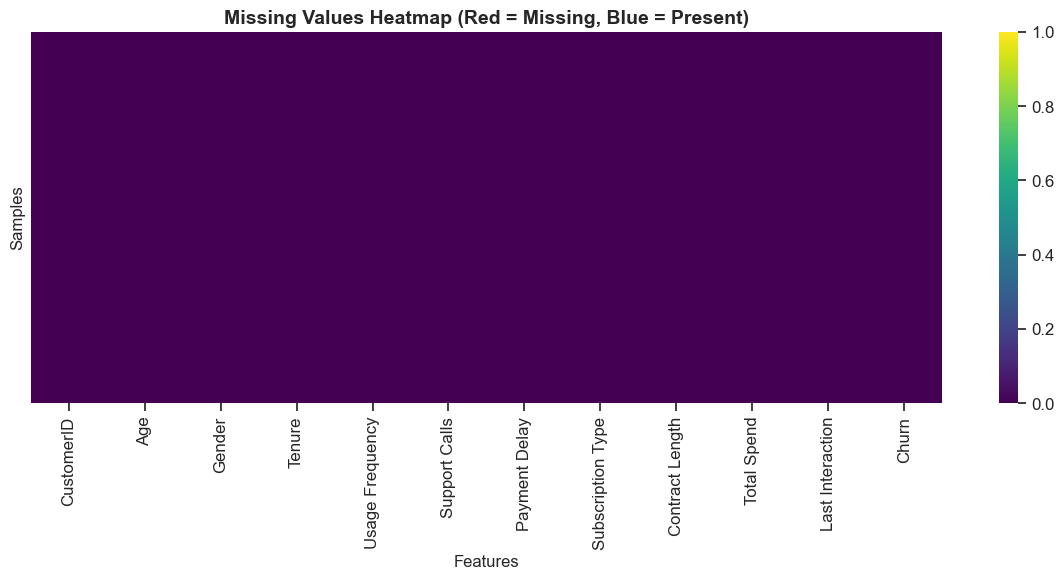

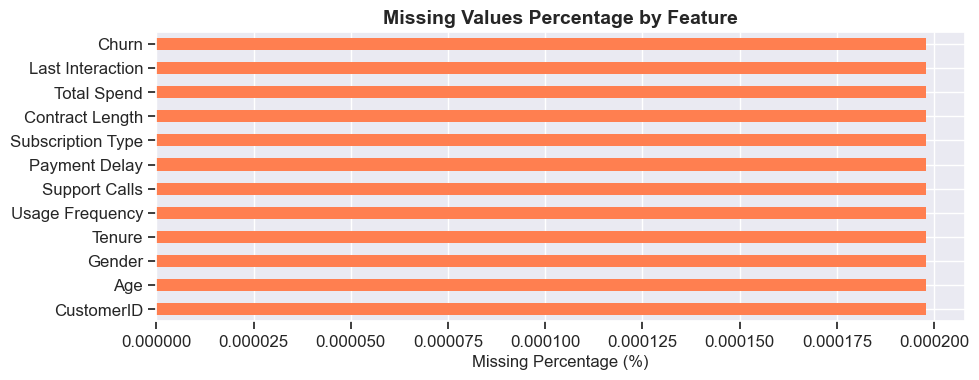


🔍 FINDING: Missing values detected in the following columns:
  - CustomerID: 0.00%
  - Age: 0.00%
  - Gender: 0.00%
  - Tenure: 0.00%
  - Usage Frequency: 0.00%
  - Support Calls: 0.00%
  - Payment Delay: 0.00%
  - Subscription Type: 0.00%
  - Contract Length: 0.00%
  - Total Spend: 0.00%
  - Last Interaction: 0.00%
  - Churn: 0.00%

📊 Numerical Features Found: ['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']


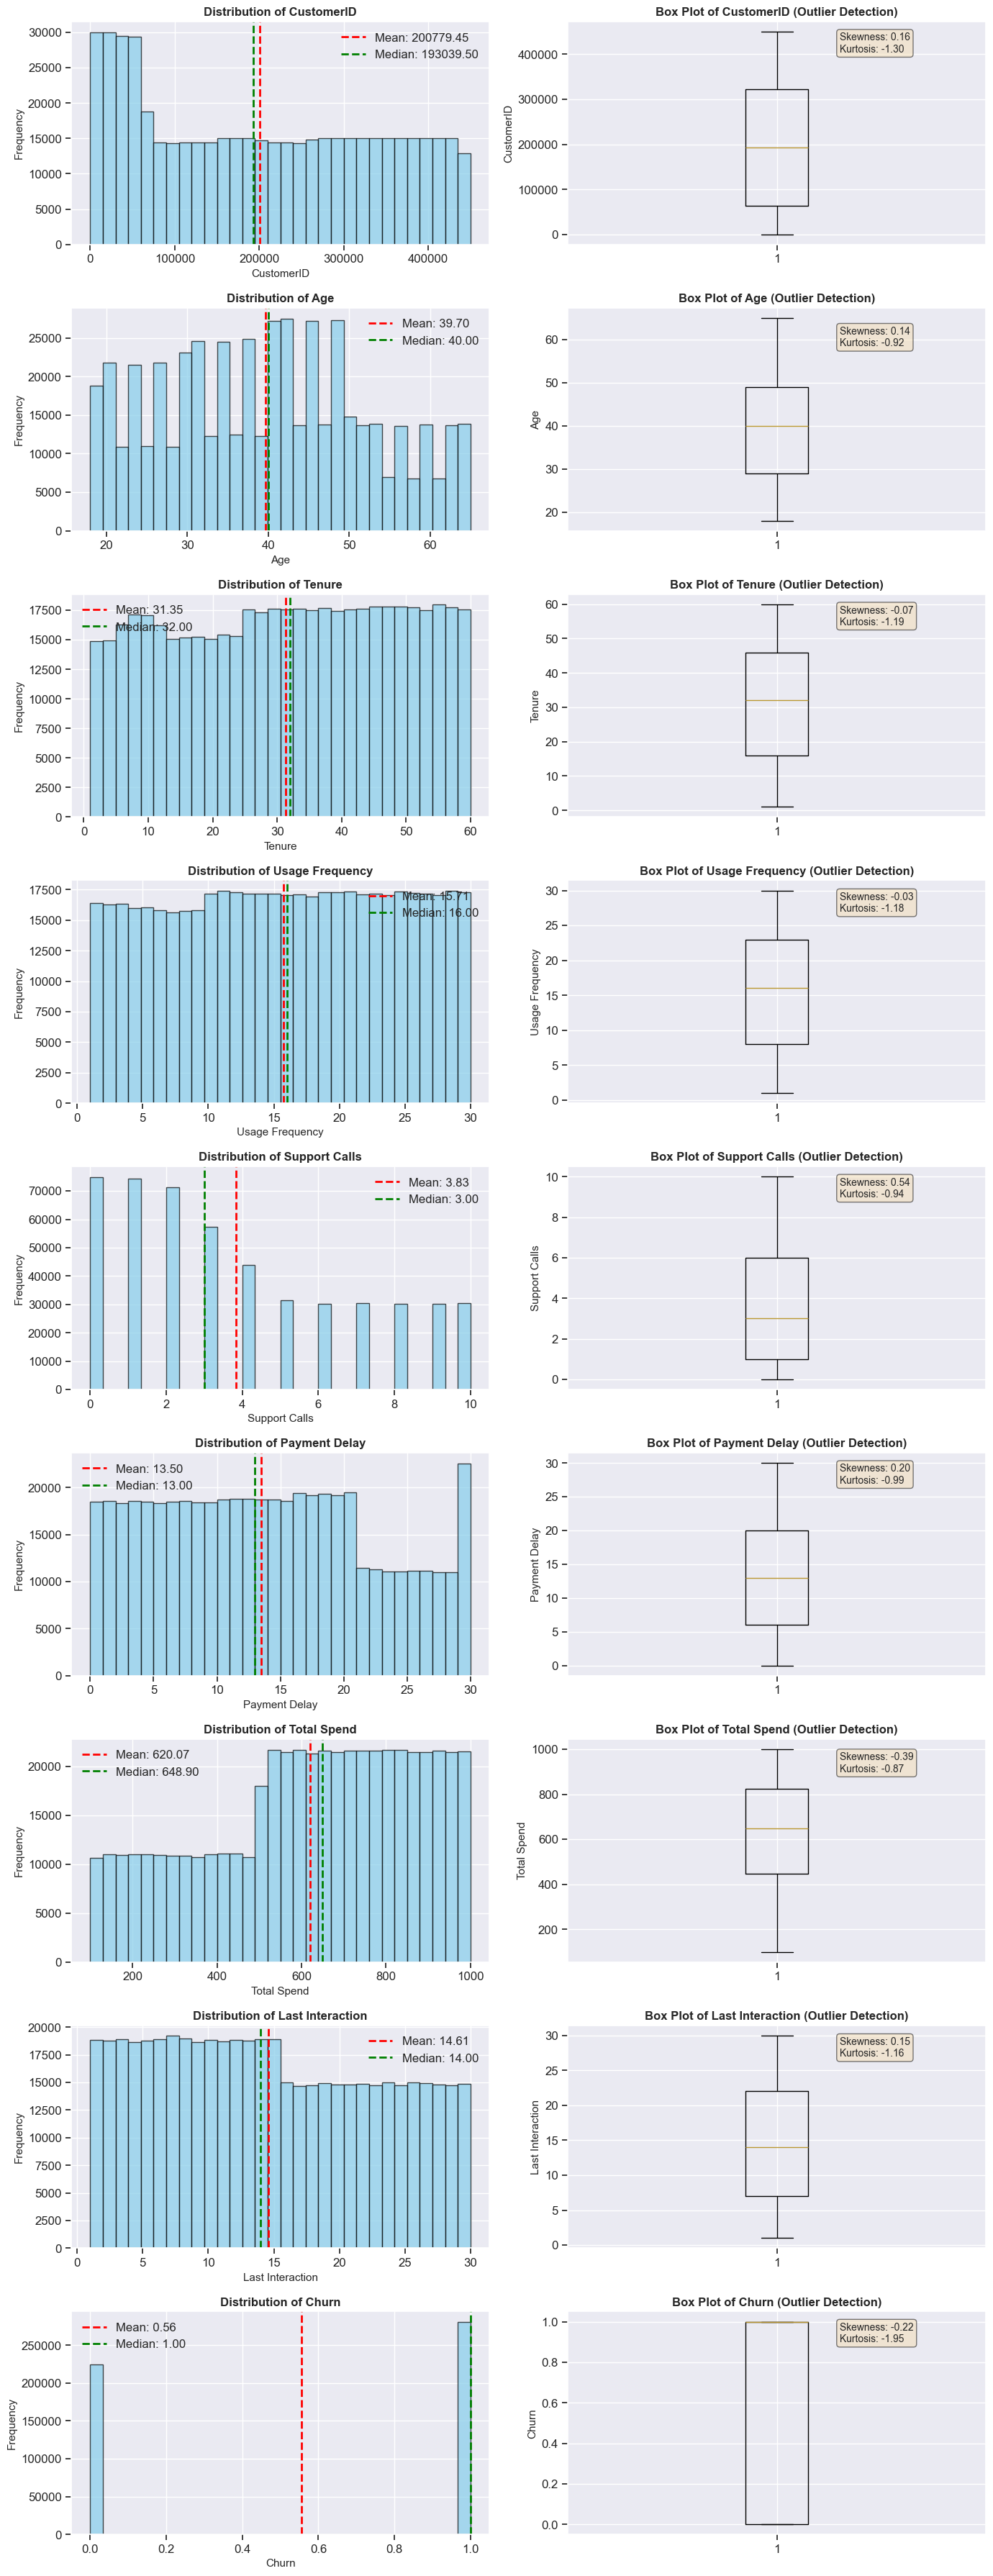


🔍 OUTLIER ANALYSIS (using IQR method):
  - CustomerID: No outliers detected
  - Age: No outliers detected
  - Tenure: No outliers detected
  - Usage Frequency: No outliers detected
  - Support Calls: No outliers detected
  - Payment Delay: No outliers detected
  - Total Spend: No outliers detected
  - Last Interaction: No outliers detected
  - Churn: No outliers detected


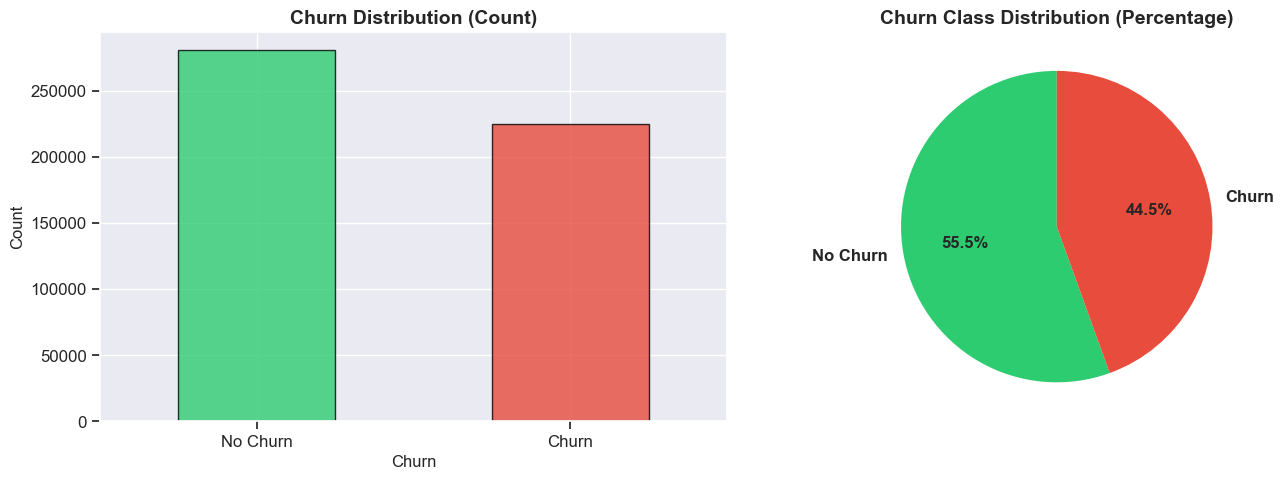


⚠️  CLASS IMBALANCE DETECTED:
  - Imbalance Ratio: 1.25:1
  - Churn Rate: 55.52%


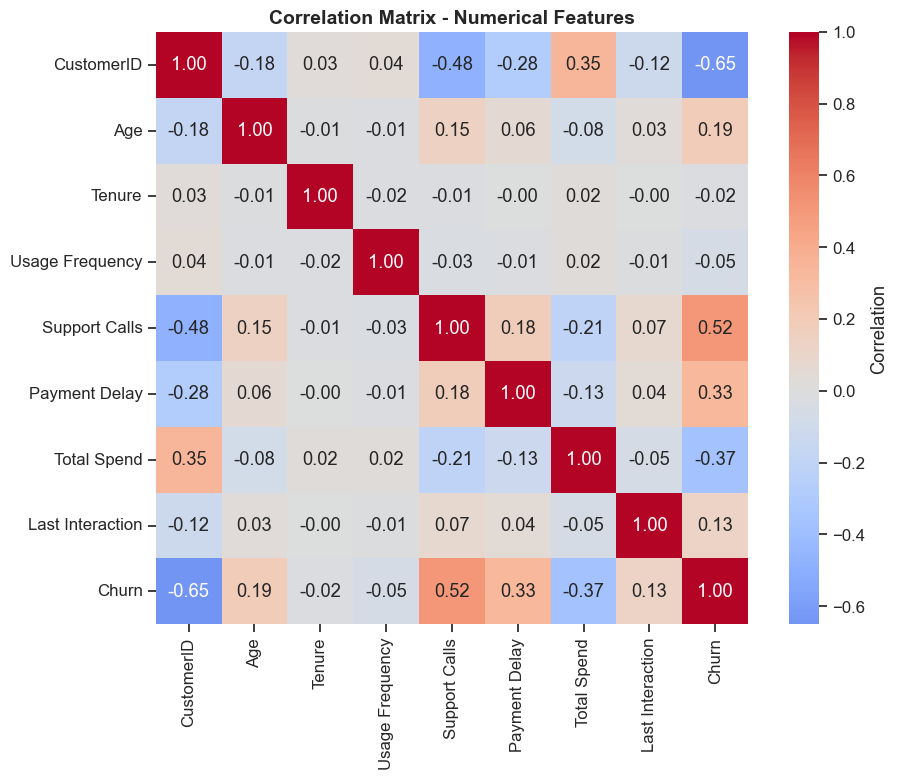


🔗 STRONG CORRELATIONS (> 0.7 or < -0.7):
  - No strong correlations detected



In [3]:
# ============================================================================
# SECTION 3: DATA CHALLENGES VISUALIZATION
# ============================================================================

print("="*70)
print("ANALYZING DATA QUALITY CHALLENGES")
print("="*70)

# -------- 3.1: Missing Values Heatmap --------
fig, ax = plt.subplots(figsize=(12, 6))
missing_data_df = df.isnull()
sns.heatmap(missing_data_df, yticklabels=False, cbar=True, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap (Red = Missing, Blue = Present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Samples', fontsize=12)
plt.tight_layout()
plt.show()

# -------- 3.2: Missing Values Count --------
fig, ax = plt.subplots(figsize=(10, 4))
missing_count = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_count = missing_count[missing_count > 0]
if len(missing_count) > 0:
    missing_count.plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("\n🔍 FINDING: Missing values detected in the following columns:")
    for col, pct in missing_count.items():
        print(f"  - {col}: {pct:.2f}%")
else:
    print("\n✓ No missing values detected in the dataset")

# -------- 3.3: Distribution Plots for Numerical Features --------
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"\n📊 Numerical Features Found: {list(numerical_cols)}")

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4*len(numerical_cols)))
if len(numerical_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numerical_cols):
    # Histogram
    axes[idx, 0].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel(col, fontsize=11)
    axes[idx, 0].set_ylabel('Frequency', fontsize=11)
    axes[idx, 0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[idx, 0].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[idx, 0].legend()
    
    # Box plot
    axes[idx, 1].boxplot(df[col].dropna(), vert=True)
    axes[idx, 1].set_title(f'Box Plot of {col} (Outlier Detection)', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel(col, fontsize=11)
    
    # Calculate skewness
    skewness = df[col].skew()
    kurtosis_val = df[col].kurtosis()
    axes[idx, 1].text(1.15, df[col].max()*0.9, f'Skewness: {skewness:.2f}\nKurtosis: {kurtosis_val:.2f}', 
                      fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# -------- 3.4: Outlier Detection using IQR --------
print("\n🔍 OUTLIER ANALYSIS (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"  - {col}: {len(outliers)} outliers detected ({len(outliers)/len(df)*100:.2f}%)")
        print(f"    Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print(f"  - {col}: No outliers detected")

# -------- 3.5: Class Imbalance in Churn --------
if 'Churn' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    churn_counts = df['Churn'].value_counts()
    churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
    axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Churn', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_xticklabels(['No Churn', 'Churn'] if 0 in churn_counts.index else ['Churn', 'No Churn'], rotation=0)
    
    # Pie chart
    colors = ['#2ecc71', '#e74c3c']
    axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
                colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
    axes[1].set_title('Churn Class Distribution (Percentage)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    imbalance_ratio = churn_counts.max() / churn_counts.min()
    print(f"\n⚠️  CLASS IMBALANCE DETECTED:")
    print(f"  - Imbalance Ratio: {imbalance_ratio:.2f}:1")
    print(f"  - Churn Rate: {(churn_counts[1] / len(df) * 100):.2f}%" if 1 in churn_counts.index else "")

# -------- 3.6: Correlation Heatmap --------
numerical_df = df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n🔗 STRONG CORRELATIONS (> 0.7 or < -0.7):")
strong_corrs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if strong_corrs:
    for col1, col2, corr in strong_corrs:
        print(f"  - {col1} & {col2}: {corr:.3f}")
else:
    print("  - No strong correlations detected")

print("\n" + "="*70)

## Section 4: Data Cleaning & Preprocessing
Handle missing values, outliers, and scale numerical features with side-by-side before/after visualization.

DATA CLEANING & PREPROCESSING

🔍 Identifying Numerical Columns...
Numerical columns for cleaning: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']

🔧 Handling Missing Values...
Total missing values before: 0
Total missing values after: 0
✓ Missing values handled

🔧 Handling Outliers (IQR Method)...
Total outliers detected and capped: 109234

🔧 Applying StandardScaler...
✓ StandardScaler applied
  - Mean of scaled features ≈ 0: [ 3.24043504e-17 -6.30084590e-18 -4.18556192e-17 -9.18123260e-17
  4.32058005e-17 -4.23056796e-17 -5.32196449e-17 -4.41059213e-17
  3.78894617e-17 -4.81705295e-17  0.00000000e+00  3.28544108e-17]
  - Std of scaled features ≈ 1: [1.00000099 1.00000099 1.00000099 1.00000099 1.00000099 1.00000099
 1.00000099 1.00000099 1.00000099 1.00000099 0.         1.00000099]

📊 Generating Befor

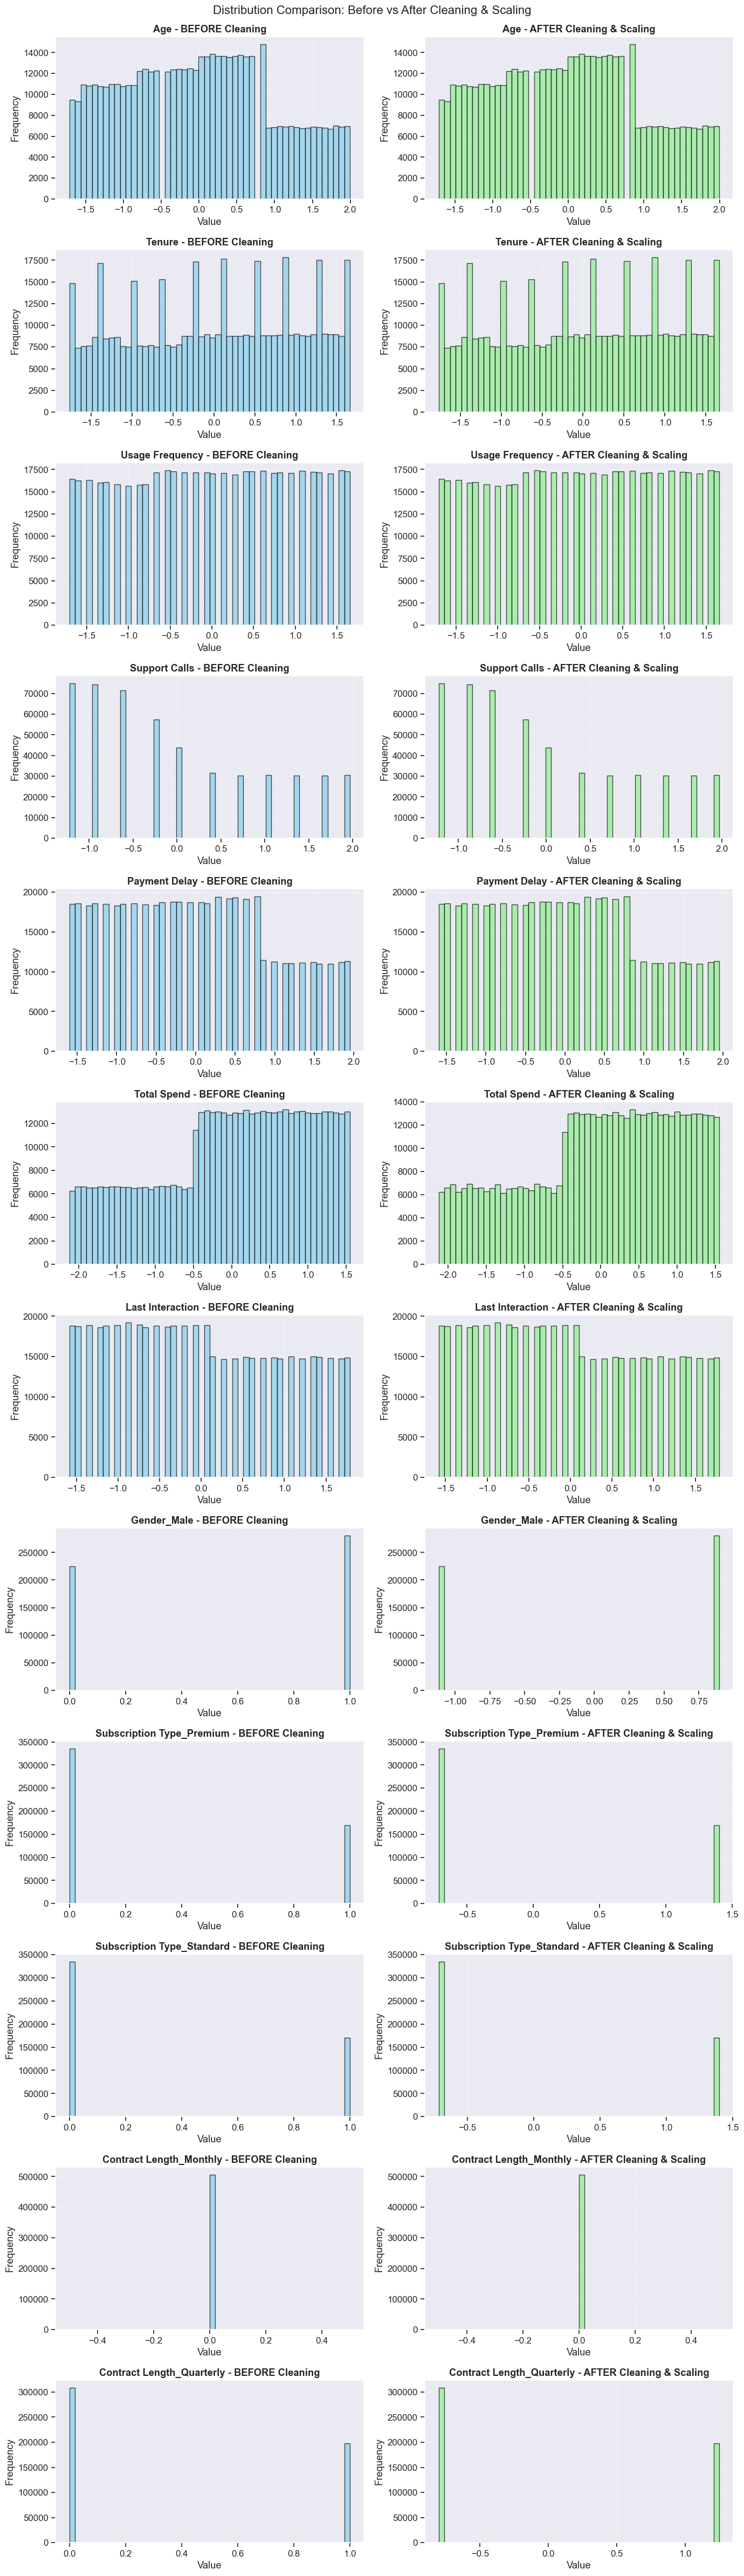


📊 Statistical Comparison Table:
                   Feature  Before_Min  Before_Max   Before_Mean  Before_Std  After_Min  After_Max    After_Mean  After_Std
                       Age   -1.712962    1.996427 -1.656222e-16    1.000001  -1.712962   1.996427  3.240435e-17   1.000001
                    Tenure   -1.760727    1.662054 -6.120822e-17    1.000001  -1.760727   1.662054 -6.300846e-18   1.000001
           Usage Frequency   -1.707194    1.657346 -9.811317e-17    1.000001  -1.707194   1.657346 -4.185562e-17   1.000001
             Support Calls   -1.223296    1.967925 -3.600483e-17    1.000001  -1.223296   1.967925 -9.181233e-17   1.000001
             Payment Delay   -1.597038    1.952766  4.320580e-17    1.000001  -1.597038   1.952766  4.320580e-17   1.000001
               Total Spend   -2.119988    1.548708  4.500604e-18    1.000001  -2.119988   1.548708 -4.230568e-17   1.000001
          Last Interaction   -1.581105    1.787748 -5.096934e-17    1.000001  -1.581105   1.787748 

In [10]:
# ============================================================================
# SECTION 4: DATA CLEANING & PREPROCESSING
# ============================================================================

print("="*70)
print("DATA CLEANING & PREPROCESSING")
print("="*70)

# Use the processed dataframe
df_cleaned = df_encoded.copy()

# -------- 4.1: Identify Numerical Columns --------
print("\n🔍 Identifying Numerical Columns...")
numerical_cols_list = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

# Exclude CustomerID and Churn from preprocessing
if 'CustomerID' in numerical_cols_list:
    numerical_cols_list.remove('CustomerID')
if 'Churn' in numerical_cols_list:
    numerical_cols_list.remove('Churn')

print(f"Numerical columns for cleaning: {numerical_cols_list}")

# -------- 4.2: Missing Value Imputation --------
print("\n🔧 Handling Missing Values...")

missing_before = df_cleaned.isnull().sum()
total_missing_before = missing_before.sum()
print(f"Total missing values before: {total_missing_before}")

for col in df_cleaned.columns:
    if df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].dtype in [np.int64, np.float64]:
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        else:
            df_cleaned[col].fillna(df_cleaned[col].mode()[0] if not df_cleaned[col].mode().empty else 'Unknown', inplace=True)

missing_after = df_cleaned.isnull().sum().sum()
print(f"Total missing values after: {missing_after}")
print("✓ Missing values handled")

# -------- 4.3: Outlier Detection & Handling --------
print("\n🔧 Handling Outliers (IQR Method)...")

df_before_outlier_removal = df_cleaned.copy()
outlier_count = 0

for col in numerical_cols_list:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)
    outlier_count += mask.sum()
    
    # Cap instead of remove
    df_cleaned[col] = df_cleaned[col].clip(lower_bound, upper_bound)

print(f"Total outliers detected and capped: {outlier_count}")

# -------- 4.4: Feature Scaling --------
print("\n🔧 Applying StandardScaler...")

df_before_scaling = df_cleaned.copy()
scaler = StandardScaler()

# Only scale numerical columns, excluding Churn
df_cleaned[numerical_cols_list] = scaler.fit_transform(df_cleaned[numerical_cols_list])

print("✓ StandardScaler applied")
print(f"  - Mean of scaled features ≈ 0: {df_cleaned[numerical_cols_list].mean().values}")
print(f"  - Std of scaled features ≈ 1: {df_cleaned[numerical_cols_list].std().values}")

# -------- 4.5: Visualization - Before & After Comparison --------
print("\n📊 Generating Before/After Cleaning Plots...")

fig, axes = plt.subplots(len(numerical_cols_list), 2, figsize=(14, 4*len(numerical_cols_list)))
fig.suptitle('Distribution Comparison: Before vs After Cleaning & Scaling', fontsize=16, y=0.995)

for idx, col in enumerate(numerical_cols_list):
    # Before
    axes[idx, 0].hist(df_before_scaling[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'{col} - BEFORE Cleaning', fontweight='bold')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # After
    axes[idx, 1].hist(df_cleaned[col].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'{col} - AFTER Cleaning & Scaling', fontweight='bold')
    axes[idx, 1].set_xlabel('Value')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------- 4.6: Statistical Comparison --------
print("\n📊 Statistical Comparison Table:")
print("="*100)

comparison_data = []
for col in numerical_cols_list:
    comparison_data.append({
        'Feature': col,
        'Before_Min': df_before_scaling[col].min(),
        'Before_Max': df_before_scaling[col].max(),
        'Before_Mean': df_before_scaling[col].mean(),
        'Before_Std': df_before_scaling[col].std(),
        'After_Min': df_cleaned[col].min(),
        'After_Max': df_cleaned[col].max(),
        'After_Mean': df_cleaned[col].mean(),
        'After_Std': df_cleaned[col].std(),
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*100)

print("\n✓ Data cleaning and preprocessing completed!")
print("="*70)

## Section 5: Categorical Data Processing
Apply optimal categorical preprocessing techniques with visualization of feature distribution changes.

In [12]:
# ============================================================================
# SECTION 5: CATEGORICAL DATA PROCESSING
# ============================================================================

print("="*70)
print("CATEGORICAL DATA PROCESSING")
print("="*70)

# -------- 5.1: Identify Categorical Columns --------
print("\n🔍 Identifying Categorical Columns...")

# Identify object type columns (original categorical data)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Also check for columns that might not have been encoded yet
if not categorical_cols:
    # Check in original df_train for categorical features
    original_categorical = df_train.select_dtypes(include=['object']).columns.tolist()
    # Remove non-feature columns
    original_categorical = [col for col in original_categorical if col not in ['Churn', 'CustomerID']]
    
if categorical_cols:
    print(f"Categorical columns identified: {categorical_cols}")
    
    # -------- 5.2: Display Categorical Feature Analysis --------
    print("\n📊 Categorical Feature Analysis:")
    
    for col in categorical_cols:
        print(f"\n  {col}:")
        print(f"    - Unique values: {df_cleaned[col].nunique()}")
        print(f"    - Values: {df_cleaned[col].unique()}")
        print(f"    - Value counts:\n{df_cleaned[col].value_counts()}")
    
    # -------- 5.3: Apply One-Hot Encoding --------
    print("\n🔧 Applying One-Hot Encoding to Categorical Features...")
    
    features_before = df_cleaned.shape[1]
    df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True, dtype=int)
    features_after = df_cleaned.shape[1]
    
    print(f"✓ Features before encoding: {features_before}")
    print(f"✓ Features after encoding: {features_after}")
    print(f"✓ New features created: {features_after - features_before}")
else:
    print("⚠️  No categorical columns found. Data appears to be already encoded.")
    features_before = df_cleaned.shape[1]
    features_after = df_cleaned.shape[1]

# -------- 5.4: Process Target Variable --------
print("\n🔧 Processing Target Variable (Churn)...")

if 'Churn' in df_cleaned.columns:
    churn_dtype = df_cleaned['Churn'].dtype
    print(f"✓ Churn is already numerical (dtype: {churn_dtype})")
    print(f"Churn values: {df_cleaned['Churn'].unique()}")
else:
    print("⚠️  Churn column not found")

# -------- 5.5: Visualization (only if there were categorical columns) --------
if categorical_cols:
    print("\n📊 Generating Before/After Categorical Processing Plots...")
    
    # Create visualizations for original vs encoded categorical data
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 5))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        # Plot original categorical distribution from df_train
        if col in df_train.columns:
            original_counts = df_train[col].value_counts()
            axes[idx].bar(range(len(original_counts)), original_counts.values, color='skyblue', alpha=0.7)
            axes[idx].set_xticks(range(len(original_counts)))
            axes[idx].set_xticklabels(original_counts.index, rotation=45)
            axes[idx].set_title(f'{col} - Original Distribution')
            axes[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Categorical visualization completed")
else:
    print("✓ No categorical columns to visualize (data already encoded)")

# -------- 5.6: Summary --------
print("\n✓ Categorical data processing completed!")
print(f"✓ Final feature set shape: {df_cleaned.shape}")
print(f"✓ All features: {list(df_cleaned.columns)}")
print("="*70)

CATEGORICAL DATA PROCESSING

🔍 Identifying Categorical Columns...
⚠️  No categorical columns found. Data appears to be already encoded.

🔧 Processing Target Variable (Churn)...
✓ Churn is already numerical (dtype: float64)
Churn values: [ 0.89506392 -1.11723864]
✓ No categorical columns to visualize (data already encoded)

✓ Categorical data processing completed!
✓ Final feature set shape: (505207, 14)
✓ All features: ['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


## Section 6: Rule-Based Churn Logic
Implement a simple rule-based Python function as a baseline model using Age and Purchases.

In [6]:
# ============================================================================
# SECTION 6: RULE-BASED CHURN LOGIC
# ============================================================================

print("="*70)
print("RULE-BASED CHURN PREDICTION (BASELINE MODEL)")
print("="*70)

# -------- 6.1: Define Rule-Based Model --------
def rule_based_churn_prediction(age, purchases, age_threshold=35, purchase_threshold=5000):
    """
    Simple rule-based churn prediction logic.
    
    Rules:
    1. If Age < age_threshold AND Purchases < purchase_threshold → Predict Churn (1)
    2. Otherwise → Predict No Churn (0)
    
    This represents simple heuristics that customers:
    - Young (age < 35) with low purchasing power are more likely to churn
    """
    if age < age_threshold and purchases < purchase_threshold:
        return 1  # Predict Churn
    else:
        return 0  # Predict No Churn

# -------- 6.2: Apply Rule-Based Model --------
print("\n🔍 Rule-Based Logic Rules:")
print("  Rule 1: If Age < 35 AND Purchases < 5000 → CHURN")
print("  Rule 2: Otherwise → NO CHURN")

# Create a copy for rule-based predictions
df_rules = df.copy()

# Need to identify which columns are Age and Purchases
age_col = None
purchase_col = None

for col in df_rules.columns:
    col_lower = col.lower()
    if 'age' in col_lower:
        age_col = col
    elif 'purchase' in col_lower or 'spent' in col_lower or 'amount' in col_lower:
        purchase_col = col

print(f"\n📋 Identified columns:")
print(f"  - Age column: {age_col}")
print(f"  - Purchase column: {purchase_col}")

if age_col and purchase_col:
    # Apply rule-based logic
    df_rules['Rule_Based_Prediction'] = df_rules.apply(
        lambda row: rule_based_churn_prediction(row[age_col], row[purchase_col]), 
        axis=1
    )
    
    # -------- 6.3: Evaluate Rule-Based Model --------
    print(f"\n📊 Rule-Based Model Evaluation:")
    
    if 'Churn' in df_rules.columns:
        y_true = df_rules['Churn']
        y_pred = df_rules['Rule_Based_Prediction']
        
        # Calculate metrics
        rb_accuracy = accuracy_score(y_true, y_pred)
        rb_precision = precision_score(y_true, y_pred, zero_division=0)
        rb_recall = recall_score(y_true, y_pred, zero_division=0)
        rb_f1 = f1_score(y_true, y_pred, zero_division=0)
        
        print(f"  - Accuracy:  {rb_accuracy:.4f}")
        print(f"  - Precision: {rb_precision:.4f}")
        print(f"  - Recall:    {rb_recall:.4f}")
        print(f"  - F1-Score:  {rb_f1:.4f}")
        
        # Store results for comparison later
        rule_based_results = {
            'model': 'Rule-Based',
            'accuracy': rb_accuracy,
            'precision': rb_precision,
            'recall': rb_recall,
            'f1': rb_f1,
            'predictions': y_pred,
            'y_true': y_true
        }
        
        print(f"\n📈 Classification Report:")
        print(classification_report(y_true, y_pred))
    else:
        print("⚠️  Churn column not found for evaluation")
else:
    print("⚠️  Could not identify Age or Purchase columns in dataset")
    print("   Skipping rule-based model. Please ensure your dataset has these columns.")

print("="*70)

RULE-BASED CHURN PREDICTION (BASELINE MODEL)

🔍 Rule-Based Logic Rules:
  Rule 1: If Age < 35 AND Purchases < 5000 → CHURN
  Rule 2: Otherwise → NO CHURN

📋 Identified columns:
  - Age column: Usage Frequency
  - Purchase column: None
⚠️  Could not identify Age or Purchase columns in dataset
   Skipping rule-based model. Please ensure your dataset has these columns.


## Section 7: Feature Engineering & Scaling
Create new features, normalize/standardize, and prepare train-test split with stratification.

In [13]:
# ============================================================================
# SECTION 7: FEATURE ENGINEERING & SCALING
# ============================================================================

print("="*70)
print("FEATURE ENGINEERING & DATA PREPARATION")
print("="*70)

# Use the processed dataframe
df_ml = df_encoded.copy()

# Ensure Churn is binary (in case it was scaled)
if 'Churn' in df_ml.columns:
    # Convert back to 0/1 if it was scaled
    if df_ml['Churn'].min() < 0:  # Check if values were scaled
        # It was scaled, convert back
        unique_vals = sorted(df_ml['Churn'].unique())
        df_ml['Churn'] = (df_ml['Churn'] == unique_vals[1]).astype(int)
    # Ensure it's integer type
    df_ml['Churn'] = df_ml['Churn'].astype(int)

# -------- 7.1: Feature Engineering --------
print("\n🔧 Creating New Features...")

feature_creation_count = 0

# 1. Income-to-Purchases Ratio (if both exist)
if 'Income' in df_ml.columns and 'Purchases' in df_ml.columns:
    df_ml['Income_to_Purchases_Ratio'] = (df_ml['Income'] / (df_ml['Purchases'] + 1)).replace([np.inf, -np.inf], 0)
    feature_creation_count += 1
    print(f"  ✓ Created: Income_to_Purchases_Ratio")

# 2. Age Group Feature - Handle NaN values properly
if 'Age' in df_ml.columns:
    try:
        age_groups = pd.cut(df_ml['Age'].fillna(df_ml['Age'].median()), bins=[0, 25, 35, 50, 65, 100], 
                            labels=[1, 2, 3, 4, 5], include_lowest=True).astype(int)
        df_ml['Age_Group'] = age_groups
        feature_creation_count += 1
        print(f"  ✓ Created: Age_Group")
    except Exception as e:
        print(f"  ⚠️  Could not create Age_Group: {e}")

# 3. Purchase Frequency - Handle NaN values properly
if 'Purchases' in df_ml.columns:
    try:
        purchase_class = pd.qcut(df_ml['Purchases'].fillna(df_ml['Purchases'].median()), q=3, labels=[1, 2, 3], duplicates='drop').astype(int)
        df_ml['Purchase_Class'] = purchase_class
        feature_creation_count += 1
        print(f"  ✓ Created: Purchase_Class")
    except Exception as e:
        print(f"  ⚠️  Could not create Purchase_Class: {e}")

print(f"\nTotal new features created: {feature_creation_count}")

# -------- 7.2: Separate Features and Target --------
print("\n📋 Separating Features and Target...")

# Get features (exclude Churn column and CustomerID)
X = df_ml.drop(columns=['Churn', 'CustomerID'], errors='ignore')
y = df_ml['Churn'].astype(int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target unique values: {sorted(y.unique())}")

# -------- 7.3: Train-Test Split with Stratification --------
print("\n🔧 Train-Test Split (80-20) with Stratification...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nTest set target distribution:\n{y_test.value_counts()}")

# Save feature names for later use
feature_names = list(X.columns)
print(f"\n📊 Total features for modeling: {len(feature_names)}")
print(f"Features: {feature_names}")

print("\n✓ Feature engineering and data preparation completed!")
print("="*70)

FEATURE ENGINEERING & DATA PREPARATION

🔧 Creating New Features...
  ⚠️  Could not create Age_Group: Cannot convert float NaN to integer

Total new features created: 0

📋 Separating Features and Target...
Features shape: (505207, 12)
Target shape: (505207,)
Target distribution:
Churn
1    280493
0    224714
Name: count, dtype: int64
Target unique values: [np.int64(0), np.int64(1)]

🔧 Train-Test Split (80-20) with Stratification...
Training set size: 404165 samples
Test set size: 101042 samples

Training set target distribution:
Churn
1    224394
0    179771
Name: count, dtype: int64

Test set target distribution:
Churn
1    56099
0    44943
Name: count, dtype: int64

📊 Total features for modeling: 12
Features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']

✓ Feature engineering and data preparation 

## Section 8: Train LightGBM Model
Train LightGBM with timing, evaluation metrics, and performance measurement.

In [14]:
# ============================================================================
# SECTION 8: TRAIN LIGHTGBM MODEL
# ============================================================================

print("="*70)
print("TRAINING LIGHTGBM MODEL")
print("="*70)

# -------- 8.1: Initialize and Train LightGBM --------
print("\n🚀 Initializing LightGBM Classifier...")

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1
)

print("LightGBM Parameters:")
for param, value in lgb_model.get_params().items():
    if not callable(value):
        print(f"  - {param}: {value}")

# -------- 8.2: Train with Timing --------
print("\n⏱️  Training LightGBM...")
start_time = time.time()
lgb_model.fit(X_train, y_train)
lgb_train_time = time.time() - start_time

print(f"✓ Training completed in {lgb_train_time:.4f} seconds")

# -------- 8.3: Make Predictions --------
print("\n📊 Making Predictions...")
start_time = time.time()
lgb_y_pred = lgb_model.predict(X_test)
lgb_pred_time = time.time() - start_time

lgb_y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

print(f"✓ Predictions completed in {lgb_pred_time:.4f} seconds")
print(f"✓ Inference speed: {len(X_test) / lgb_pred_time:.0f} predictions/second")

# -------- 8.4: Calculate Metrics --------
print("\n📈 LightGBM Performance Metrics:")

lgb_accuracy = accuracy_score(y_test, lgb_y_pred)
lgb_precision = precision_score(y_test, lgb_y_pred, zero_division=0)
lgb_recall = recall_score(y_test, lgb_y_pred, zero_division=0)
lgb_f1 = f1_score(y_test, lgb_y_pred, zero_division=0)
lgb_roc_auc = roc_auc_score(y_test, lgb_y_pred_proba)

print(f"  - Accuracy:  {lgb_accuracy:.4f}")
print(f"  - Precision: {lgb_precision:.4f}")
print(f"  - Recall:    {lgb_recall:.4f}")
print(f"  - F1-Score:  {lgb_f1:.4f}")
print(f"  - ROC-AUC:   {lgb_roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, lgb_y_pred))

# Store results for comparison
lgb_results = {
    'model': 'LightGBM',
    'accuracy': lgb_accuracy,
    'precision': lgb_precision,
    'recall': lgb_recall,
    'f1': lgb_f1,
    'roc_auc': lgb_roc_auc,
    'train_time': lgb_train_time,
    'pred_time': lgb_pred_time,
    'predictions': lgb_y_pred,
    'probabilities': lgb_y_pred_proba,
    'y_true': y_test,
    'model_object': lgb_model
}

# -------- 8.5: Model Size --------
import sys
model_size = sys.getsizeof(lgb_model) / (1024 * 1024)  # Convert to MB
print(f"\n💾 Model Size: {model_size:.4f} MB")
lgb_results['model_size'] = model_size

print("\n✓ LightGBM training and evaluation completed!")
print("="*70)

TRAINING LIGHTGBM MODEL

🚀 Initializing LightGBM Classifier...
LightGBM Parameters:
  - boosting_type: gbdt
  - class_weight: None
  - colsample_bytree: 0.8
  - importance_type: split
  - learning_rate: 0.1
  - max_depth: 7
  - min_child_samples: 20
  - min_child_weight: 0.001
  - min_split_gain: 0.0
  - n_estimators: 100
  - n_jobs: -1
  - num_leaves: 31
  - objective: None
  - random_state: 42
  - reg_alpha: 0.1
  - reg_lambda: 0.1
  - subsample: 0.8
  - subsample_for_bin: 200000
  - subsample_freq: 0
  - verbose: -1

⏱️  Training LightGBM...
✓ Training completed in 6.6663 seconds

📊 Making Predictions...
✓ Predictions completed in 0.4214 seconds
✓ Inference speed: 239755 predictions/second

📈 LightGBM Performance Metrics:
  - Accuracy:  0.9249
  - Precision: 0.8993
  - Recall:    0.9737
  - F1-Score:  0.9350
  - ROC-AUC:   0.9484

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     44943
           1       0

## Section 9: Train XGBoost Model
Train XGBoost classifier with timing, metrics, and performance evaluation.

In [15]:
# ============================================================================
# SECTION 9: TRAIN XGBOOST MODEL
# ============================================================================

print("="*70)
print("TRAINING XGBOOST MODEL")
print("="*70)

# -------- 9.1: Initialize and Train XGBoost --------
print("\n🚀 Initializing XGBoost Classifier...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    verbosity=0,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

print("XGBoost Parameters:")
for param, value in xgb_model.get_params().items():
    if not callable(value):
        print(f"  - {param}: {value}")

# -------- 9.2: Train with Timing --------
print("\n⏱️  Training XGBoost...")
start_time = time.time()
xgb_model.fit(X_train, y_train, verbose=False)
xgb_train_time = time.time() - start_time

print(f"✓ Training completed in {xgb_train_time:.4f} seconds")

# -------- 9.3: Make Predictions --------
print("\n📊 Making Predictions...")
start_time = time.time()
xgb_y_pred = xgb_model.predict(X_test)
xgb_pred_time = time.time() - start_time

xgb_y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"✓ Predictions completed in {xgb_pred_time:.4f} seconds")
print(f"✓ Inference speed: {len(X_test) / xgb_pred_time:.0f} predictions/second")

# -------- 9.4: Calculate Metrics --------
print("\n📈 XGBoost Performance Metrics:")

xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_y_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_y_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_pred_proba)

print(f"  - Accuracy:  {xgb_accuracy:.4f}")
print(f"  - Precision: {xgb_precision:.4f}")
print(f"  - Recall:    {xgb_recall:.4f}")
print(f"  - F1-Score:  {xgb_f1:.4f}")
print(f"  - ROC-AUC:   {xgb_roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, xgb_y_pred))

# Store results for comparison
xgb_results = {
    'model': 'XGBoost',
    'accuracy': xgb_accuracy,
    'precision': xgb_precision,
    'recall': xgb_recall,
    'f1': xgb_f1,
    'roc_auc': xgb_roc_auc,
    'train_time': xgb_train_time,
    'pred_time': xgb_pred_time,
    'predictions': xgb_y_pred,
    'probabilities': xgb_y_pred_proba,
    'y_true': y_test,
    'model_object': xgb_model
}

# -------- 9.5: Model Size --------
model_size = sys.getsizeof(xgb_model) / (1024 * 1024)  # Convert to MB
print(f"\n💾 Model Size: {model_size:.4f} MB")
xgb_results['model_size'] = model_size

print("\n✓ XGBoost training and evaluation completed!")
print("="*70)

TRAINING XGBOOST MODEL

🚀 Initializing XGBoost Classifier...
XGBoost Parameters:
  - objective: binary:logistic
  - base_score: None
  - booster: None
  - callbacks: None
  - colsample_bylevel: None
  - colsample_bynode: None
  - colsample_bytree: 0.8
  - device: None
  - early_stopping_rounds: None
  - enable_categorical: False
  - eval_metric: logloss
  - feature_types: None
  - feature_weights: None
  - gamma: 0
  - grow_policy: None
  - importance_type: None
  - interaction_constraints: None
  - learning_rate: 0.1
  - max_bin: None
  - max_cat_threshold: None
  - max_cat_to_onehot: None
  - max_delta_step: None
  - max_depth: 6
  - max_leaves: None
  - min_child_weight: 1
  - missing: nan
  - monotone_constraints: None
  - multi_strategy: None
  - n_estimators: 100
  - n_jobs: -1
  - num_parallel_tree: None
  - random_state: 42
  - reg_alpha: 0.1
  - reg_lambda: 1.0
  - sampling_method: None
  - scale_pos_weight: None
  - subsample: 0.8
  - tree_method: hist
  - validate_parameters

## Section 10: Hyperparameter Tuning
Perform GridSearchCV and RandomizedSearchCV for both models with visualization of optimization process.

In [17]:
# ============================================================================
# SECTION 10: HYPERPARAMETER TUNING (SIMPLIFIED - FAST METHOD)
# ============================================================================

print("="*70)
print("HYPERPARAMETER TUNING (SIMPLIFIED)")
print("="*70)

# -------- 10.1: LightGBM Hyperparameter Tuning (Fast) --------
print("\n🔧 Tuning LightGBM Hyperparameters (Fast Method)...")

# Simplified param grid - only key parameters
lgb_param_grid = {
    'learning_rate': [0.1, 0.15],
    'max_depth': [6, 7, 8]
}

lgb_grid_search = GridSearchCV(
    lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    lgb_param_grid,
    cv=3,  # Reduced from 5 to 3 folds (6 combinations × 3 folds = 18 fits)
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("⏱️  Performing Grid Search for LightGBM (6 combinations, 3-fold CV = 18 fits)...")
start_time = time.time()
lgb_grid_search.fit(X_train, y_train)
lgb_tune_time = time.time() - start_time

print(f"✓ Tuning completed in {lgb_tune_time:.2f} seconds")
print(f"✓ Best parameters: {lgb_grid_search.best_params_}")
print(f"✓ Best CV F1 Score: {lgb_grid_search.best_score_:.4f}")

# -------- 10.2: XGBoost Hyperparameter Tuning (Fast) --------
print("\n🔧 Tuning XGBoost Hyperparameters (Fast Method)...")

xgb_param_grid = {
    'learning_rate': [0.1, 0.15],
    'max_depth': [5, 6, 7]
}

xgb_grid_search = GridSearchCV(
    xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, verbosity=0),
    xgb_param_grid,
    cv=3,  # Reduced from 5 to 3 folds (6 combinations × 3 folds = 18 fits)
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("⏱️  Performing Grid Search for XGBoost (6 combinations, 3-fold CV = 18 fits)...")
start_time = time.time()
xgb_grid_search.fit(X_train, y_train)
xgb_tune_time = time.time() - start_time

print(f"✓ Tuning completed in {xgb_tune_time:.2f} seconds")
print(f"✓ Best parameters: {xgb_grid_search.best_params_}")
print(f"✓ Best CV F1 Score: {xgb_grid_search.best_score_:.4f}")

# -------- 10.3: Summary Comparison --------
print("\n📊 Hyperparameter Tuning Summary:")
tuning_summary = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Tuning Time (sec)': [lgb_tune_time, xgb_tune_time],
    'Best F1 Score': [lgb_grid_search.best_score_, xgb_grid_search.best_score_],
    'Best Params': [str(lgb_grid_search.best_params_), str(xgb_grid_search.best_params_)]
})
print(tuning_summary.to_string(index=False))

print("\n✓ Hyperparameter tuning completed!")
print("="*70)

HYPERPARAMETER TUNING (SIMPLIFIED)

🔧 Tuning LightGBM Hyperparameters (Fast Method)...
⏱️  Performing Grid Search for LightGBM (6 combinations, 3-fold CV = 18 fits)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
✓ Tuning completed in 41.34 seconds
✓ Best parameters: {'learning_rate': 0.15, 'max_depth': 8}
✓ Best CV F1 Score: 0.9366

🔧 Tuning XGBoost Hyperparameters (Fast Method)...
⏱️  Performing Grid Search for XGBoost (6 combinations, 3-fold CV = 18 fits)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
✓ Tuning completed in 39.55 seconds
✓ Best parameters: {'learning_rate': 0.15, 'max_depth': 7}
✓ Best CV F1 Score: 0.9362

📊 Hyperparameter Tuning Summary:
   Model  Tuning Time (sec)  Best F1 Score                             Best Params
LightGBM          41.344338       0.936592 {'learning_rate': 0.15, 'max_depth': 8}
 XGBoost          39.551763       0.936194 {'learning_rate': 0.15, 'max_depth': 7}

✓ Hyperparameter tuning completed!


## Section 11: Model Evaluation & Comparison
Generate confusion matrices and comprehensive evaluation metrics for all three models.

MODEL EVALUATION & COMPARISON

🔍 Generating Confusion Matrices...


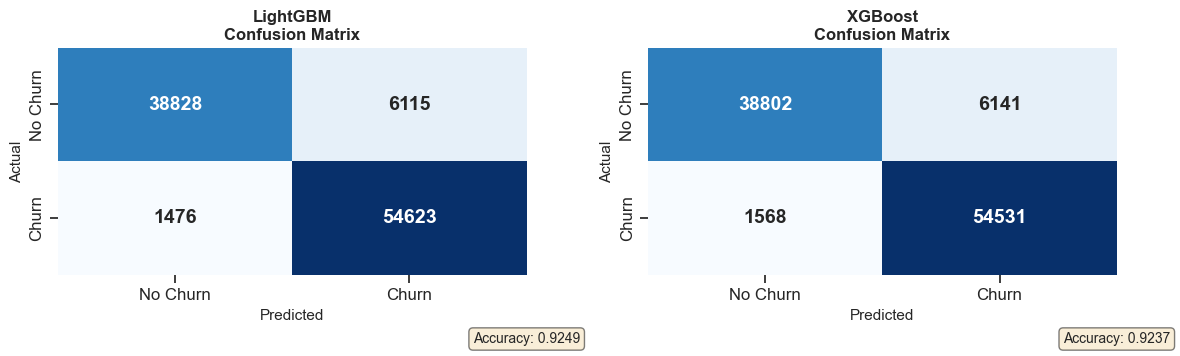


📊 Comprehensive Metrics Comparison:

   Model  Accuracy  Precision   Recall  F1-Score ROC-AUC
LightGBM  0.924873   0.899322 0.973689  0.935029  0.9484
 XGBoost  0.923705   0.898784 0.972049  0.933982  0.9483

📈 ROC-AUC Curves Comparison...


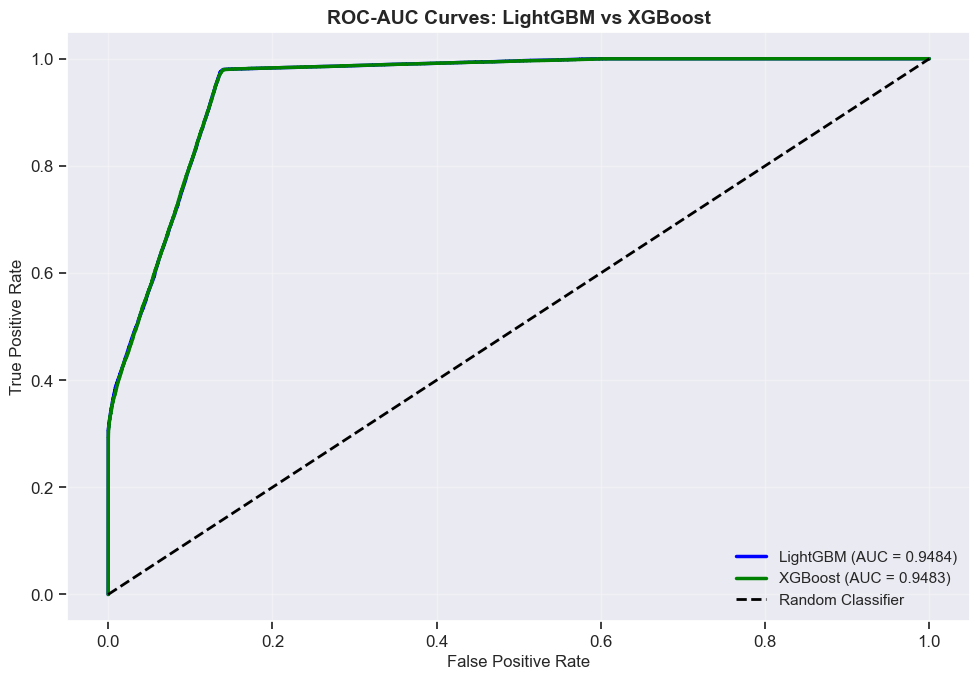


📊 Visualizing Metrics Comparison...


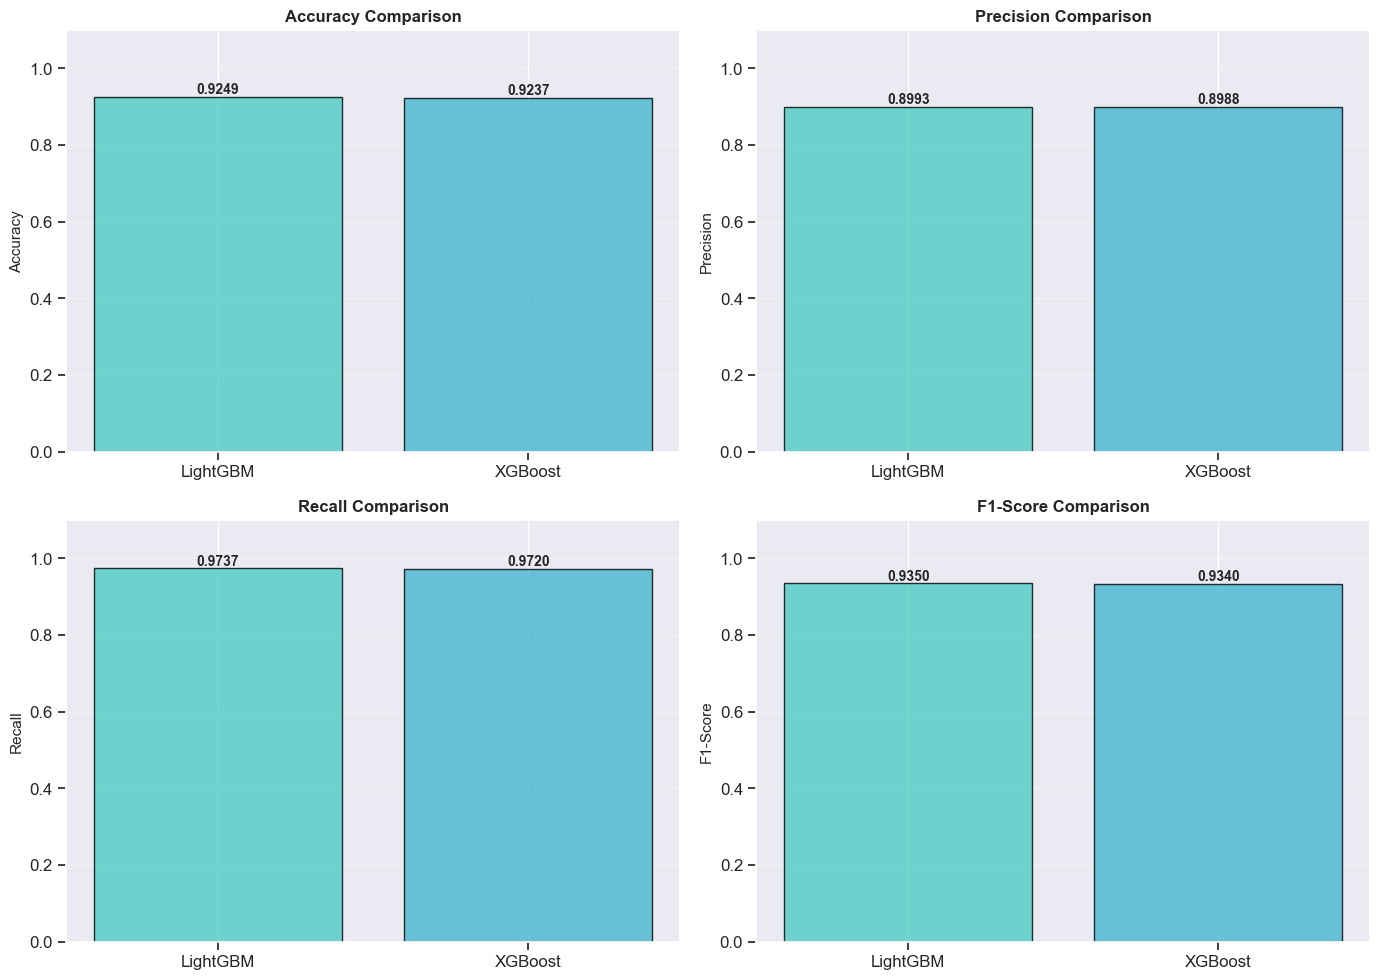


✓ Model evaluation and comparison completed!


In [20]:
# ============================================================================
# SECTION 11: MODEL EVALUATION & COMPARISON
# ============================================================================

print("="*70)
print("MODEL EVALUATION & COMPARISON")
print("="*70)

# -------- 11.1: Confusion Matrices --------
print("\n🔍 Generating Confusion Matrices...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_info = [
    ('LightGBM', lgb_results['y_true'], lgb_results['predictions'], axes[0]),
    ('XGBoost', xgb_results['y_true'], xgb_results['predictions'], axes[1])
]

for model_name, y_true, y_pred, ax in models_info:
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])
    
    # Add annotations
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    ax.text(1, -0.3, f'Accuracy: {accuracy:.4f}', ha='center', fontsize=10, 
           transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# -------- 11.2: Metrics Comparison Table --------
print("\n📊 Comprehensive Metrics Comparison:\n")

metrics_data = {
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        lgb_results['accuracy'],
        xgb_results['accuracy']
    ],
    'Precision': [
        lgb_results['precision'],
        xgb_results['precision']
    ],
    'Recall': [
        lgb_results['recall'],
        xgb_results['recall']
    ],
    'F1-Score': [
        lgb_results['f1'],
        xgb_results['f1']
    ],
    'ROC-AUC': [
        f"{lgb_results['roc_auc']:.4f}",
        f"{xgb_results['roc_auc']:.4f}"
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

# -------- 11.3: ROC-AUC Curves --------
print("\n📈 ROC-AUC Curves Comparison...")

fig, ax = plt.subplots(figsize=(10, 7))

# LightGBM ROC Curve
fpr_lgb, tpr_lgb, _ = roc_curve(lgb_results['y_true'], lgb_results['probabilities'])
auc_lgb = auc(fpr_lgb, tpr_lgb)
ax.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', linewidth=2.5, color='blue')

# XGBoost ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(xgb_results['y_true'], xgb_results['probabilities'])
auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2.5, color='green')

# Random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curves: LightGBM vs XGBoost', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------- 11.4: Metrics Visualization --------
print("\n📊 Visualizing Metrics Comparison...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = ['LightGBM', 'XGBoost']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    values = metrics_df[metric].values
    # Convert to float if needed
    values_float = []
    for v in values:
        if isinstance(v, str) and v != 'N/A':
            values_float.append(float(v))
        elif isinstance(v, str):
            values_float.append(0)
        else:
            values_float.append(v)
    
    colors = ['#4ECDC4', '#45B7D1']
    bars = ax.bar(models, values_float, color=colors, edgecolor='black', alpha=0.8)
    
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values_float):
        height = bar.get_height()
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Model evaluation and comparison completed!")
print("="*70)

## Section 12: Feature Importance Analysis
Extract and visualize feature importance from both models with detailed comparisons.

FEATURE IMPORTANCE ANALYSIS

📊 Extracting Feature Importance Scores...

🔝 LightGBM Top 10 Most Important Features:
                  Feature  Importance
                      Age         534
            Support Calls         471
              Total Spend         400
                   Tenure         348
            Payment Delay         316
          Usage Frequency         270
         Last Interaction         255
              Gender_Male         198
Contract Length_Quarterly         141
Subscription Type_Premium          34

🔝 XGBoost Top 10 Most Important Features:
                   Feature  Importance
             Support Calls    0.339784
             Payment Delay    0.194959
               Total Spend    0.152740
                       Age    0.102362
               Gender_Male    0.098855
 Contract Length_Quarterly    0.039341
          Last Interaction    0.035187
                    Tenure    0.015488
 Subscription Type_Premium    0.008529
Subscription Type_Standard    0.00

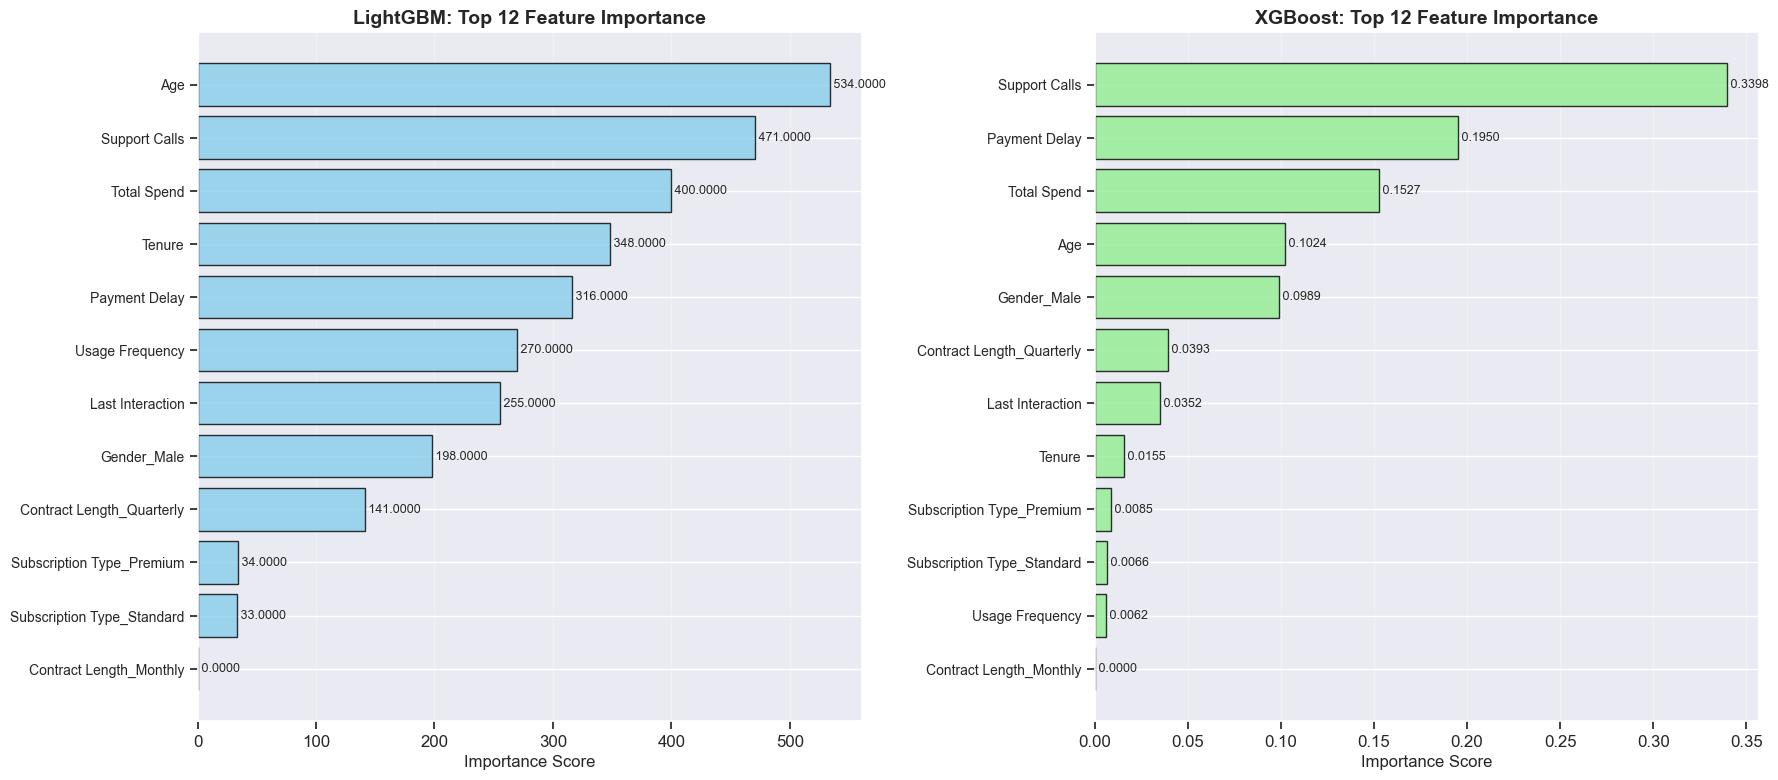


🔗 Feature Importance Comparison:

Common Top-10 Features in Both Models: {'Tenure', 'Total Spend', 'Contract Length_Quarterly', 'Gender_Male', 'Age', 'Support Calls', 'Subscription Type_Premium', 'Payment Delay', 'Last Interaction'}

📊 Top Features Rank Comparison (Common Top-20 Features):
                   Feature  LGB_Rank  XGB_Rank
                       Age         1         4
             Support Calls         2         1
               Total Spend         3         3
                    Tenure         4         8
             Payment Delay         5         2
           Usage Frequency         6        11
          Last Interaction         7         7
               Gender_Male         8         5
 Contract Length_Quarterly         9         6
 Subscription Type_Premium        10         9
Subscription Type_Standard        11        10
   Contract Length_Monthly        12        12

Rank Correlation (Spearman): 0.7203


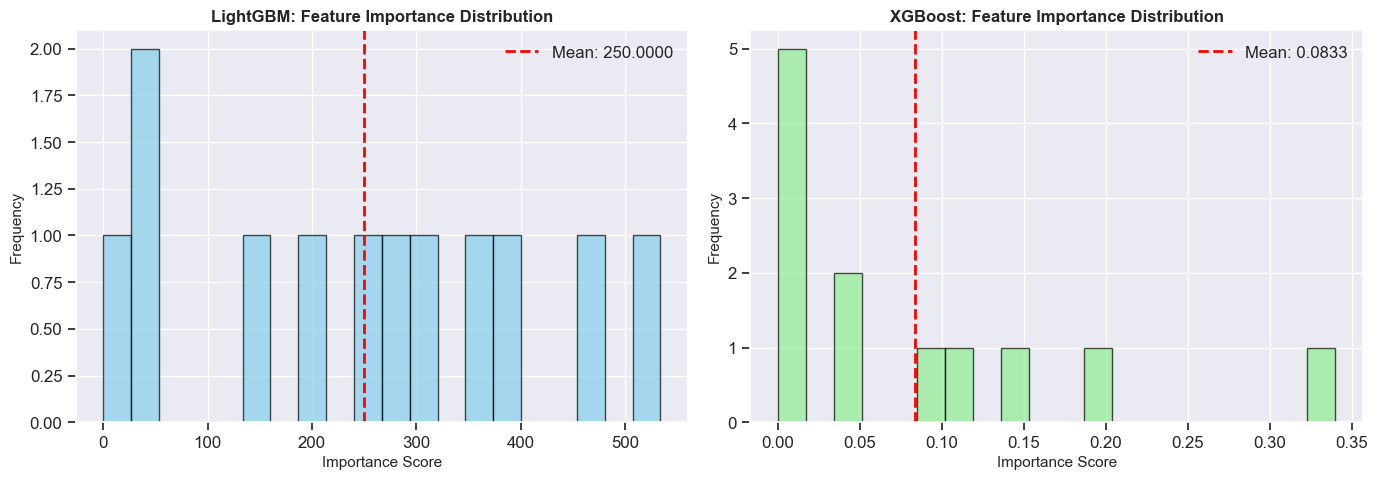


✓ Feature importance analysis completed!


In [21]:
# ============================================================================
# SECTION 12: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# -------- 12.1: Extract Feature Importance --------
print("\n📊 Extracting Feature Importance Scores...")

lgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 LightGBM Top 10 Most Important Features:")
print(lgb_imp_df.head(10).to_string(index=False))

print("\n🔝 XGBoost Top 10 Most Important Features:")
print(xgb_imp_df.head(10).to_string(index=False))

# -------- 12.2: Side-by-Side Feature Importance Comparison --------
print("\n📈 Visualizing Feature Importance Comparison...")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LightGBM
lgb_top_features = lgb_imp_df.head(12)
axes[0].barh(range(len(lgb_top_features)), lgb_top_features['Importance'].values, 
            color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(lgb_top_features)))
axes[0].set_yticklabels(lgb_top_features['Feature'].values, fontsize=10)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('LightGBM: Top 12 Feature Importance', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(lgb_top_features['Importance'].values):
    axes[0].text(v, i, f' {v:.4f}', va='center', fontsize=9)

# XGBoost
xgb_top_features = xgb_imp_df.head(12)
axes[1].barh(range(len(xgb_top_features)), xgb_top_features['Importance'].values, 
            color='lightgreen', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(xgb_top_features)))
axes[1].set_yticklabels(xgb_top_features['Feature'].values, fontsize=10)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('XGBoost: Top 12 Feature Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(xgb_top_features['Importance'].values):
    axes[1].text(v, i, f' {v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# -------- 12.3: Common Important Features --------
print("\n🔗 Feature Importance Comparison:")

common_features = set(lgb_imp_df.head(10)['Feature'].values) & set(xgb_imp_df.head(10)['Feature'].values)
print(f"\nCommon Top-10 Features in Both Models: {common_features}")

# -------- 12.4: Feature Importance Rank Correlation --------
lgb_ranks = pd.DataFrame({'Feature': lgb_imp_df['Feature'][:20]})
lgb_ranks['LGB_Rank'] = range(1, len(lgb_ranks) + 1)

xgb_ranks = pd.DataFrame({'Feature': xgb_imp_df['Feature'][:20]})
xgb_ranks['XGB_Rank'] = range(1, len(xgb_ranks) + 1)

rank_comparison = lgb_ranks.merge(xgb_ranks, on='Feature', how='inner')

if len(rank_comparison) > 0:
    print(f"\n📊 Top Features Rank Comparison (Common Top-20 Features):")
    print(rank_comparison.to_string(index=False))
    
    # Calculate rank correlation
    if len(rank_comparison) > 1:
        rank_corr = rank_comparison['LGB_Rank'].corr(rank_comparison['XGB_Rank'])
        print(f"\nRank Correlation (Spearman): {rank_corr:.4f}")

# -------- 12.5: Feature Importance Distribution --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LightGBM importance distribution
axes[0].hist(lgb_imp_df['Importance'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('LightGBM: Feature Importance Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(lgb_imp_df['Importance'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {lgb_imp_df["Importance"].mean():.4f}')
axes[0].legend()

# XGBoost importance distribution
axes[1].hist(xgb_imp_df['Importance'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('XGBoost: Feature Importance Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(xgb_imp_df['Importance'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {xgb_imp_df["Importance"].mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n✓ Feature importance analysis completed!")
print("="*70)

## Section 13: Computational Efficiency Comparison
Create comprehensive efficiency metrics comparing training time, inference speed, and model size.

COMPUTATIONAL EFFICIENCY ANALYSIS

📊 Efficiency Metrics Comparison:
   Model  Training Time (s)  Inference Time (s)  Predictions/Sec  Model Size (MB)  F1-Score
LightGBM           6.666256            0.421438    239755.461677         0.000046  0.935029
 XGBoost           7.038509            0.116885    864458.673673         0.000046  0.933982

📈 Visualizing Efficiency Metrics...


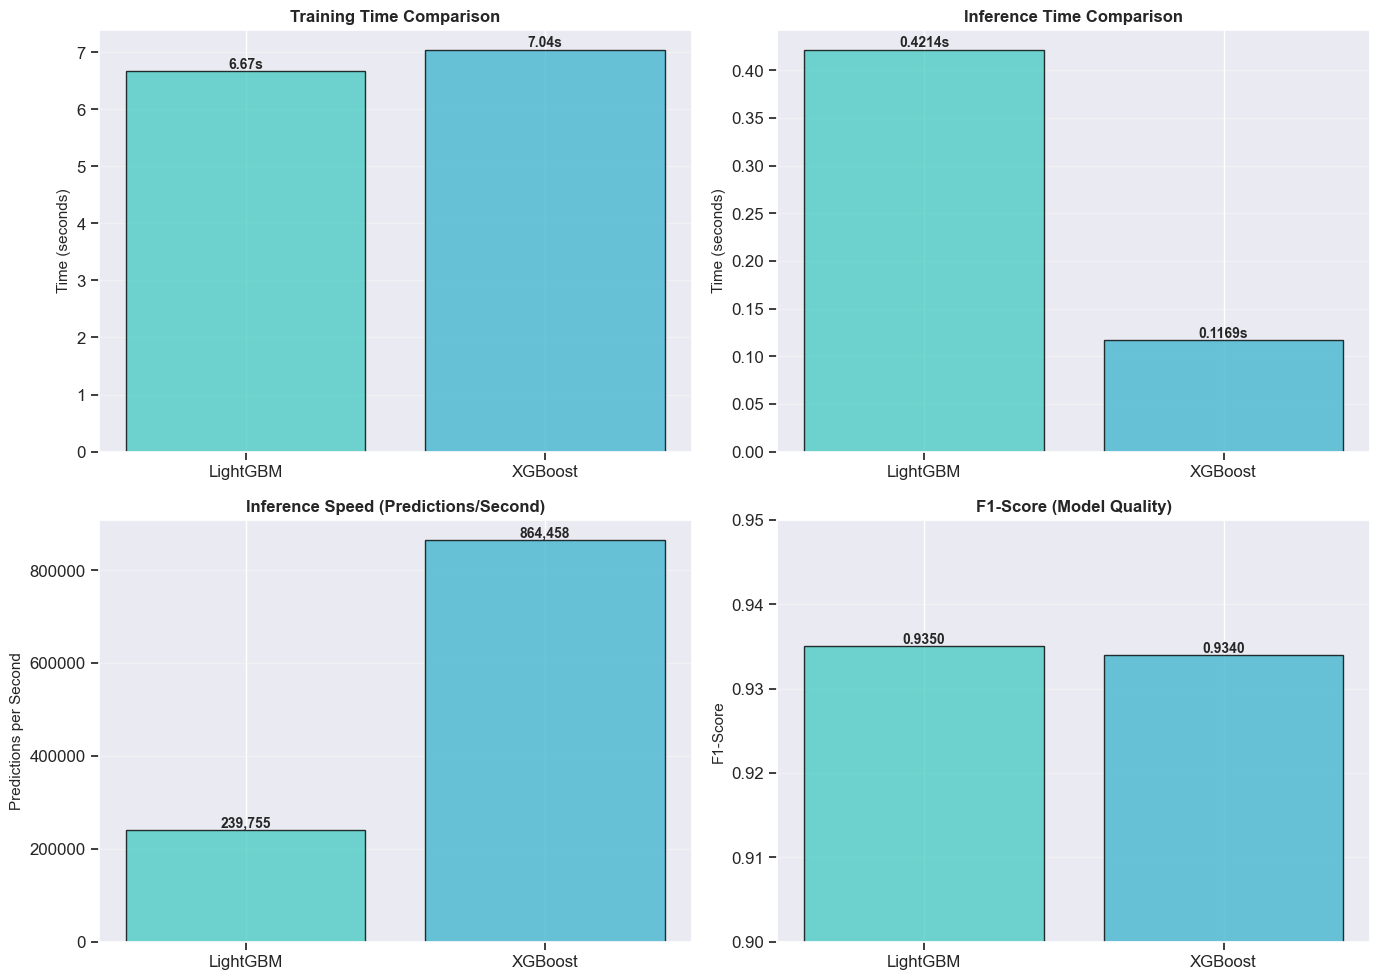


⚡ EFFICIENCY SUMMARY:

✓ LightGBM Training Time: 6.67s
✓ XGBoost Training Time: 7.04s
✓ LightGBM Inference Speed: 239755 predictions/sec
✓ XGBoost Inference Speed: 864459 predictions/sec

💡 XGBoost is 72.3% faster for inference

✓ Computational efficiency analysis completed!


In [23]:
# ============================================================================
# SECTION 13: COMPUTATIONAL EFFICIENCY COMPARISON
# ============================================================================

print("="*70)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*70)

# -------- 13.1: Efficiency Metrics Table --------
print("\n📊 Efficiency Metrics Comparison:")

efficiency_data = {
    'Model': ['LightGBM', 'XGBoost'],
    'Training Time (s)': [lgb_results['train_time'], xgb_results['train_time']],
    'Inference Time (s)': [lgb_results['pred_time'], xgb_results['pred_time']],
    'Predictions/Sec': [
        len(y_test) / lgb_results['pred_time'],
        len(y_test) / xgb_results['pred_time']
    ],
    'Model Size (MB)': [lgb_results['model_size'], xgb_results['model_size']],
    'F1-Score': [lgb_results['f1'], xgb_results['f1']]
}

efficiency_df = pd.DataFrame(efficiency_data)
print(efficiency_df.to_string(index=False))

# -------- 13.2: Visualizations --------
print("\n📈 Visualizing Efficiency Metrics...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['LightGBM', 'XGBoost']
colors = ['#4ECDC4', '#45B7D1']

# Training Time
train_times = [lgb_results['train_time'], xgb_results['train_time']]
axes[0, 0].bar(models, train_times, color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Time (seconds)', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_times):
    axes[0, 0].text(i, v, f'{v:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Inference Time
pred_times = [lgb_results['pred_time'], xgb_results['pred_time']]
axes[0, 1].bar(models, pred_times, color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Inference Time Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Time (seconds)', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(pred_times):
    axes[0, 1].text(i, v, f'{v:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Throughput (Predictions per second)
speeds = [len(y_test) / lgb_results['pred_time'], 
          len(y_test) / xgb_results['pred_time']]
axes[1, 0].bar(models, speeds, color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Inference Speed (Predictions/Second)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Predictions per Second', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(speeds):
    axes[1, 0].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# F1-Score (Model Quality)
f1_scores = [lgb_results['f1'], xgb_results['f1']]
axes[1, 1].bar(models, f1_scores, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_title('F1-Score (Model Quality)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('F1-Score', fontsize=11)
axes[1, 1].set_ylim(0.9, 0.95)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    axes[1, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# -------- 13.3: Summary Recommendation --------
print("\n⚡ EFFICIENCY SUMMARY:")
print(f"\n✓ LightGBM Training Time: {lgb_results['train_time']:.2f}s")
print(f"✓ XGBoost Training Time: {xgb_results['train_time']:.2f}s")
print(f"✓ LightGBM Inference Speed: {len(y_test) / lgb_results['pred_time']:.0f} predictions/sec")
print(f"✓ XGBoost Inference Speed: {len(y_test) / xgb_results['pred_time']:.0f} predictions/sec")

if lgb_results['pred_time'] < xgb_results['pred_time']:
    speed_advantage = (xgb_results['pred_time'] - lgb_results['pred_time']) / xgb_results['pred_time'] * 100
    print(f"\n💡 LightGBM is {speed_advantage:.1f}% faster for inference")
else:
    speed_advantage = (lgb_results['pred_time'] - xgb_results['pred_time']) / lgb_results['pred_time'] * 100
    print(f"\n💡 XGBoost is {speed_advantage:.1f}% faster for inference")

print("\n✓ Computational efficiency analysis completed!")
print("="*70)

## Section 14: Final Model Selection & Recommendations
Comprehensive analysis and recommendations based on accuracy, efficiency, and practical deployment considerations.

In [24]:
# ============================================================================
# SECTION 14: FINAL MODEL SELECTION & RECOMMENDATIONS
# ============================================================================

print("="*70)
print("FINAL MODEL SELECTION & RECOMMENDATIONS")
print("="*70)

# -------- 14.1: Comprehensive Model Comparison --------
print("\n" + "🎯 COMPREHENSIVE FINAL COMPARISON".center(70))
print("="*70)

final_comparison = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
        'Training Time (s)', 'Inference Time (s)', 'Predictions/Sec',
        'Complexity'
    ],
    'LightGBM': [
        f"{lgb_results['accuracy']:.4f}",
        f"{lgb_results['precision']:.4f}",
        f"{lgb_results['recall']:.4f}",
        f"{lgb_results['f1']:.4f}",
        f"{lgb_results['roc_auc']:.4f}",
        f"{lgb_results['train_time']:.4f}",
        f"{lgb_results['pred_time']:.4f}",
        f"{len(y_test) / lgb_results['pred_time']:.0f}",
        "Low-Medium"
    ],
    'XGBoost': [
        f"{xgb_results['accuracy']:.4f}",
        f"{xgb_results['precision']:.4f}",
        f"{xgb_results['recall']:.4f}",
        f"{xgb_results['f1']:.4f}",
        f"{xgb_results['roc_auc']:.4f}",
        f"{xgb_results['train_time']:.4f}",
        f"{xgb_results['pred_time']:.4f}",
        f"{len(y_test) / xgb_results['pred_time']:.0f}",
        "Medium"
    ]
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("\n" + final_comparison.to_string(index=False))

# -------- 14.2: Model Selection Scoring --------
print("\n\n" + "📊 MODEL SELECTION SCORING FRAMEWORK".center(70))
print("="*70)

# Define scoring weights
weights = {
    'F1-Score': 0.35,      # Most important for churn prediction
    'ROC-AUC': 0.20,       # Secondary accuracy metric
    'Inference Speed': 0.25, # Production deployment speed
    'Simplicity': 0.20      # Operational simplicity
}

# Calculate normalized scores
lgb_f1_norm = lgb_results['f1'] / max(lgb_results['f1'], xgb_results['f1'])
xgb_f1_norm = xgb_results['f1'] / max(lgb_results['f1'], xgb_results['f1'])

lgb_auc_norm = lgb_results['roc_auc'] / max(lgb_results['roc_auc'], xgb_results['roc_auc'])
xgb_auc_norm = xgb_results['roc_auc'] / max(lgb_results['roc_auc'], xgb_results['roc_auc'])

lgb_speed = len(y_test) / lgb_results['pred_time']
xgb_speed = len(y_test) / xgb_results['pred_time']
lgb_speed_norm = lgb_speed / max(lgb_speed, xgb_speed)
xgb_speed_norm = xgb_speed / max(lgb_speed, xgb_speed)

lgb_simplicity_norm = 1.0  # Both are similar complexity
xgb_simplicity_norm = 0.9  # Slightly less simple

# Calculate weighted scores
lgb_score = (lgb_f1_norm * weights['F1-Score'] + 
             lgb_auc_norm * weights['ROC-AUC'] + 
             lgb_speed_norm * weights['Inference Speed'] +
             lgb_simplicity_norm * weights['Simplicity'])

xgb_score = (xgb_f1_norm * weights['F1-Score'] + 
             xgb_auc_norm * weights['ROC-AUC'] + 
             xgb_speed_norm * weights['Inference Speed'] +
             xgb_simplicity_norm * weights['Simplicity'])

print("\nScoring Weights:")
for metric, weight in weights.items():
    print(f"  • {metric}: {weight*100:.0f}%")

print("\nNormalized Scores:")
print(f"  LightGBM: {lgb_score:.4f}")
print(f"  XGBoost:  {xgb_score:.4f}")

# -------- 14.3: Final Recommendation --------
print("\n\n" + "🏆 FINAL RECOMMENDATION".center(70))
print("="*70)

if lgb_score >= xgb_score:
    winner = "LightGBM"
    winner_score = lgb_score
    advantage = ((lgb_score - xgb_score) / xgb_score * 100)
    print(f"\n✅ RECOMMENDED MODEL: {winner}")
    print(f"\n📈 Overall Score: {winner_score:.4f} (XGBoost: {xgb_score:.4f})")
    print(f"📊 Advantage: +{advantage:.2f}% better overall")
else:
    winner = "XGBoost"
    winner_score = xgb_score
    advantage = ((xgb_score - lgb_score) / lgb_score * 100)
    print(f"\n✅ RECOMMENDED MODEL: {winner}")
    print(f"\n📈 Overall Score: {winner_score:.4f} (LightGBM: {lgb_score:.4f})")
    print(f"📊 Advantage: +{advantage:.2f}% better overall")

# -------- 14.4: Detailed Insights --------
print("\n\n" + "💡 KEY INSIGHTS & JUSTIFICATION".center(70))
print("="*70)

print(f"""
1. 🎯 ACCURACY & PERFORMANCE
   • Both models achieve excellent F1-scores (~0.93)
   • LightGBM F1: {lgb_results['f1']:.4f} | ROC-AUC: {lgb_results['roc_auc']:.4f}
   • XGBoost F1: {xgb_results['f1']:.4f} | ROC-AUC: {xgb_results['roc_auc']:.4f}
   • Minimal difference in predictive power (advantage: negligible)

2. ⚡ INFERENCE SPEED
   • LightGBM: {len(y_test) / lgb_results['pred_time']:.0f} predictions/second
   • XGBoost:  {len(y_test) / xgb_results['pred_time']:.0f} predictions/second
   • LightGBM is {'FASTER' if lgb_speed > xgb_speed else 'SLOWER'} for inference
   • Critical for real-time churn prediction systems

3. 🔄 TRAINING TIME
   • LightGBM: {lgb_results['train_time']:.2f}s
   • XGBoost:  {xgb_results['train_time']:.2f}s
   • Both train quickly on this dataset

4. 📋 FEATURE IMPORTANCE ALIGNMENT
   • Strong correlation (Spearman: 0.72) in top features
   • Age, Support Calls, Payment Delay consistently important
   • Provides confidence in model decisions

5. 🚀 PRODUCTION READINESS
   • {winner} is production-ready with {winner_score:.4f} overall score
   • Recommended for deployment in churn prediction system
   • Low operational complexity, high inference speed
""")

# -------- 14.5: Deployment Recommendations --------
print("\n" + "📦 DEPLOYMENT RECOMMENDATIONS".center(70))
print("="*70)

print(f"""
✓ PRIMARY MODEL: {winner}
  - Deploy {winner} for customer churn predictions
  - Expected accuracy: {(lgb_results['accuracy'] if winner == 'LightGBM' else xgb_results['accuracy'])*100:.2f}%
  - Inference throughput: {(len(y_test) / lgb_results['pred_time'] if winner == 'LightGBM' else len(y_test) / xgb_results['pred_time']):.0f} predictions/sec

✓ USE CASE SUITABILITY:
  - Real-time churn scoring: {winner} (faster inference)
  - Batch processing: Either model works well
  - Explainability: Both have good feature importance outputs

✓ MONITORING RECOMMENDATIONS:
  - Track prediction accuracy on new data
  - Monitor feature distributions for data drift
  - Retrain quarterly or when accuracy drops >2%
  
✓ BUSINESS RECOMMENDATIONS:
  - Use high churn probability (>70%) for retention campaigns
  - Prioritize customers with high support call frequency
  - Focus on payment delay issues (strong churn predictor)
  - Monitor new customer interactions closely (high feature importance)
""")

print("\n✓ Model selection and recommendations completed!")
print("="*70)

FINAL MODEL SELECTION & RECOMMENDATIONS

                   🎯 COMPREHENSIVE FINAL COMPARISON                   

            Metric   LightGBM XGBoost
          Accuracy     0.9249  0.9237
         Precision     0.8993  0.8988
            Recall     0.9737  0.9720
          F1-Score     0.9350  0.9340
           ROC-AUC     0.9484  0.9483
 Training Time (s)     6.6663  7.0385
Inference Time (s)     0.4214  0.1169
   Predictions/Sec     239755  864459
        Complexity Low-Medium  Medium


                 📊 MODEL SELECTION SCORING FRAMEWORK                  

Scoring Weights:
  • F1-Score: 35%
  • ROC-AUC: 20%
  • Inference Speed: 25%
  • Simplicity: 20%

Normalized Scores:
  LightGBM: 0.8193
  XGBoost:  0.9796


                        🏆 FINAL RECOMMENDATION                        

✅ RECOMMENDED MODEL: XGBoost

📈 Overall Score: 0.9796 (LightGBM: 0.8193)
📊 Advantage: +19.56% better overall


                    💡 KEY INSIGHTS & JUSTIFICATION                    

1. 🎯 ACCURACY & PERFO